# Normalization and Convex Optimization Investigation

In this notebook, we will explore the non-negativity of f constraint and its affect on the optimal solution. Also we want to see if we can normalize in such a way that keeps the comparative analysis of cell cycling genes valid.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


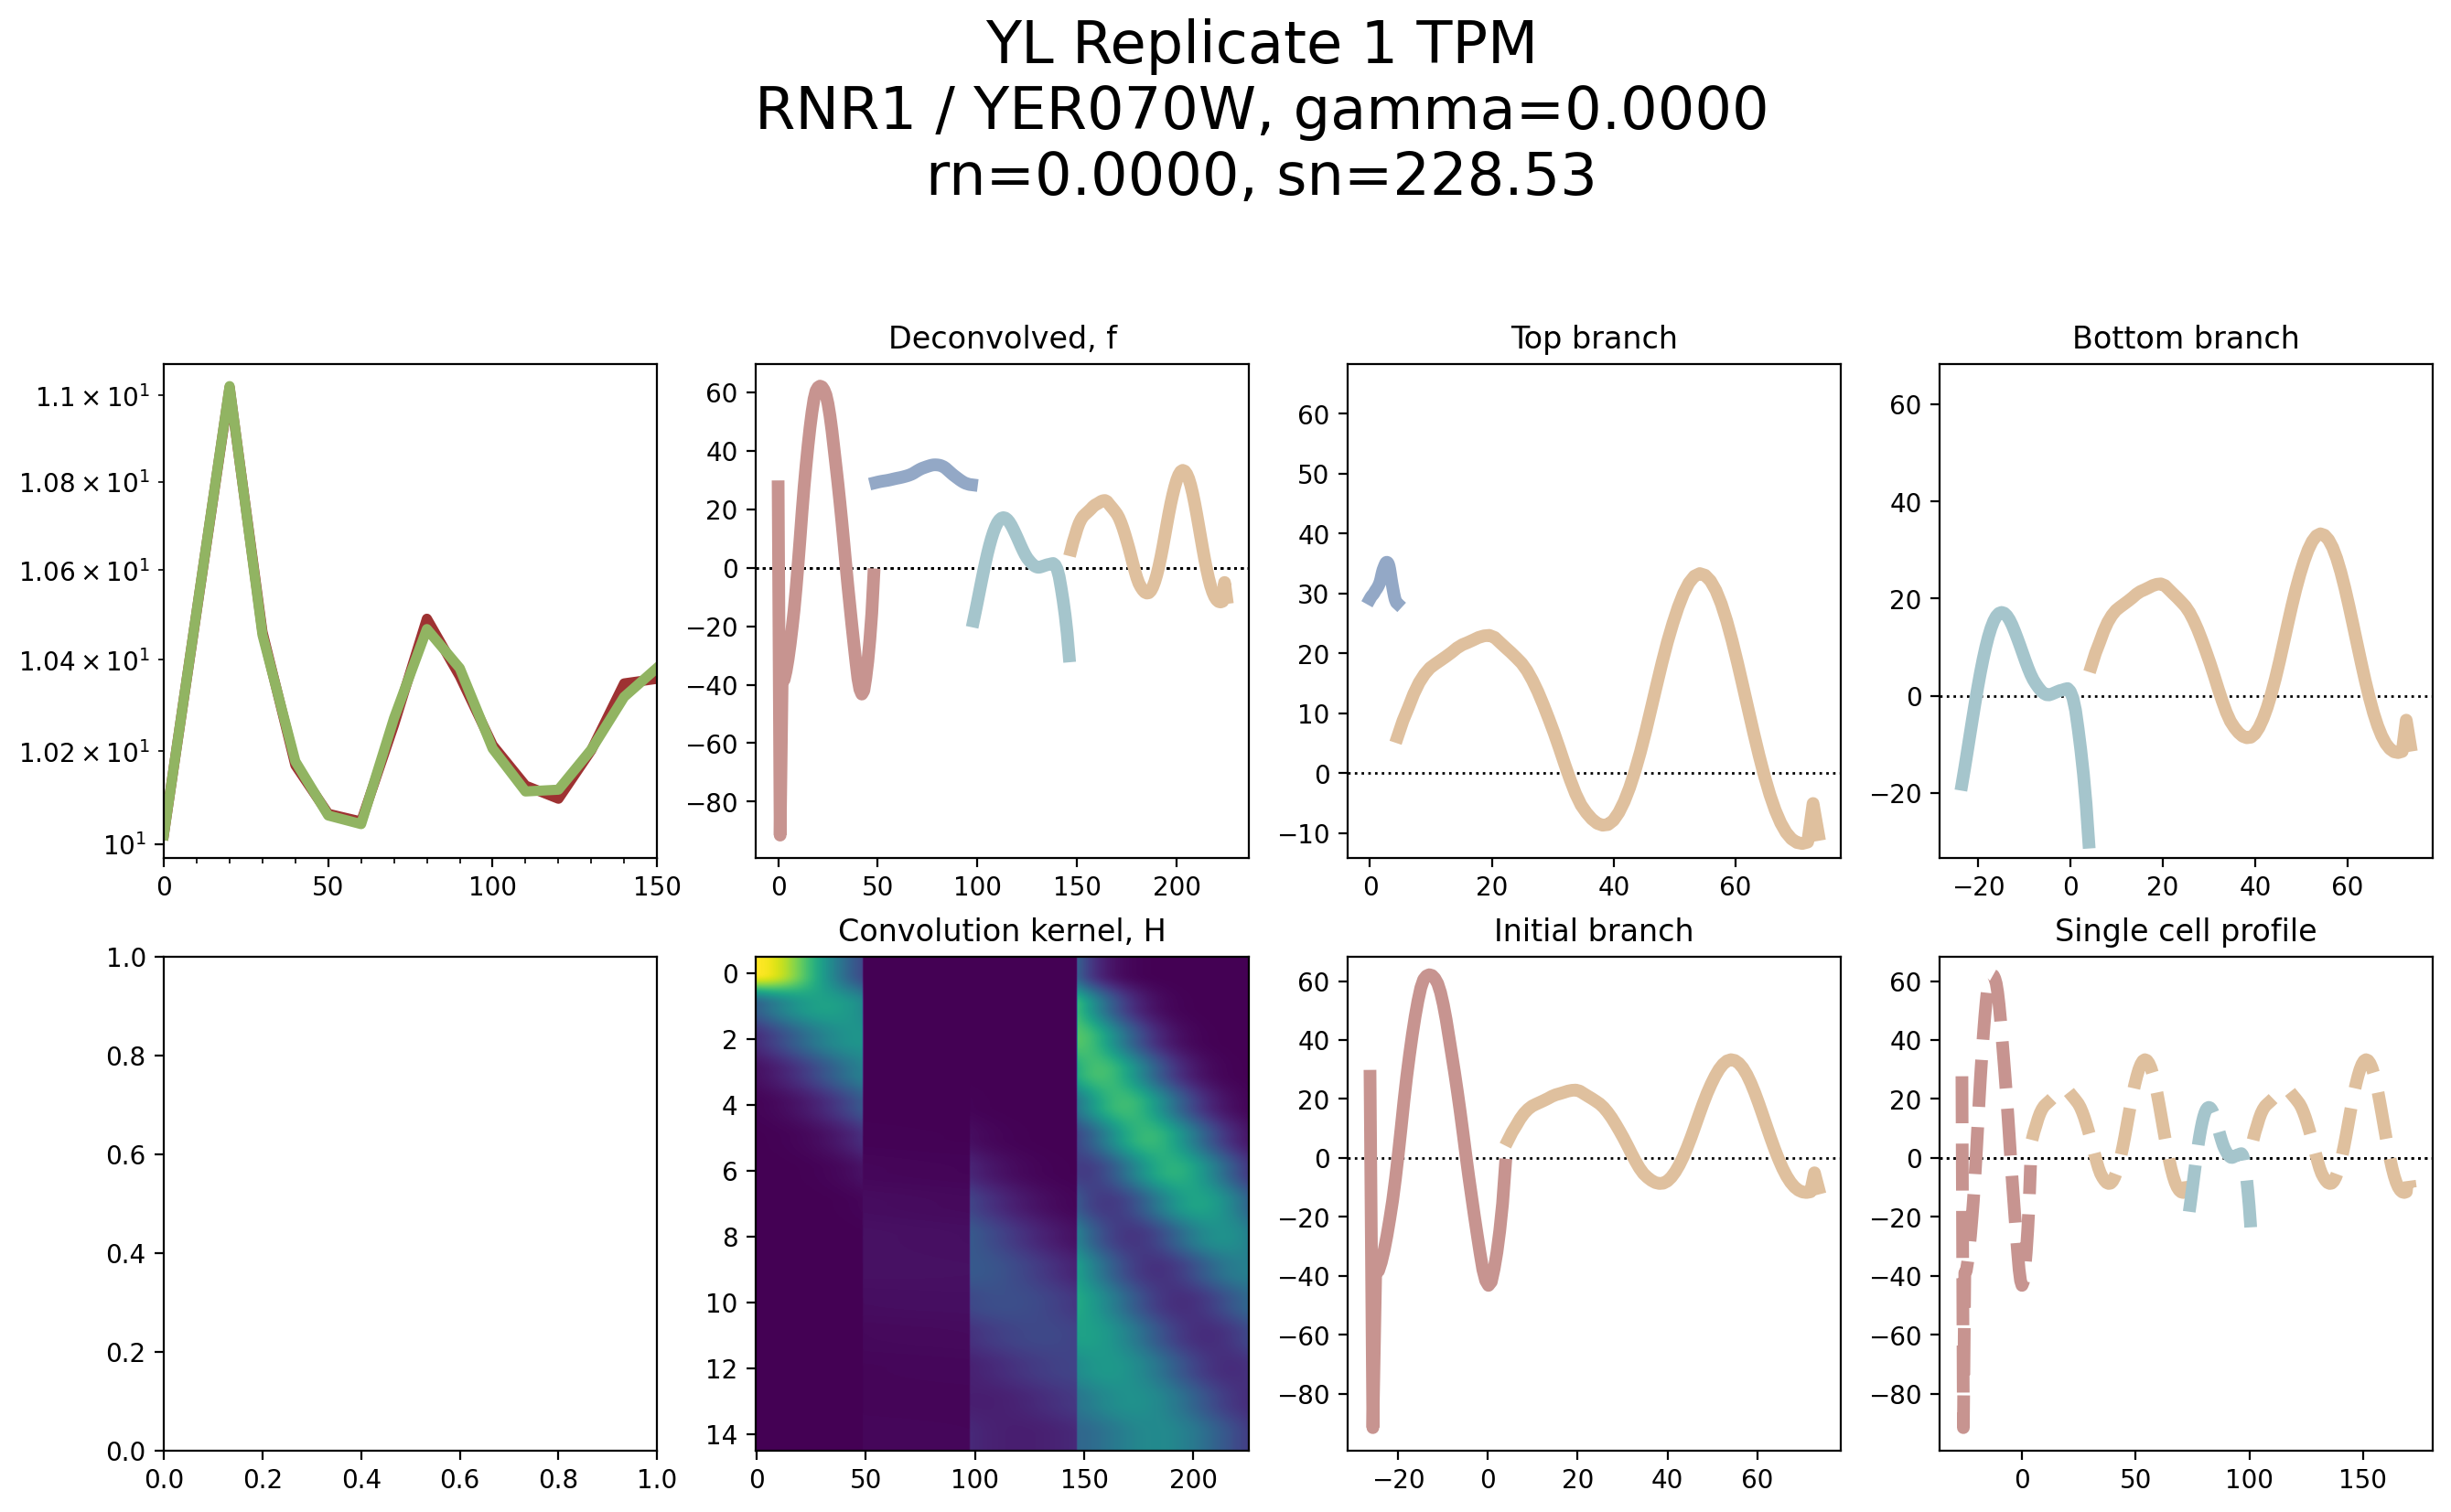

In [50]:
from src.config import load_yl_replicate1_rg1_TPM_config
from src.model import Model

tpm_config = load_yl_replicate1_rg1_TPM_config()
tpm_model = Model(config=tpm_config, gamma=0.0, gene_or_orfname='RNR1')

tpm_model.g
diff = np.max(tpm_model.g) - np.min(tpm_model.g)

tpm_model.g = tpm_model.g / diff + 10
tpm_model.g1 = tpm_model.g1 / diff + 10

tpm_model.deconvolve()

tpm_model.plot_deconvolved_gene()

(18.157057689732632, 938.3654839646116)

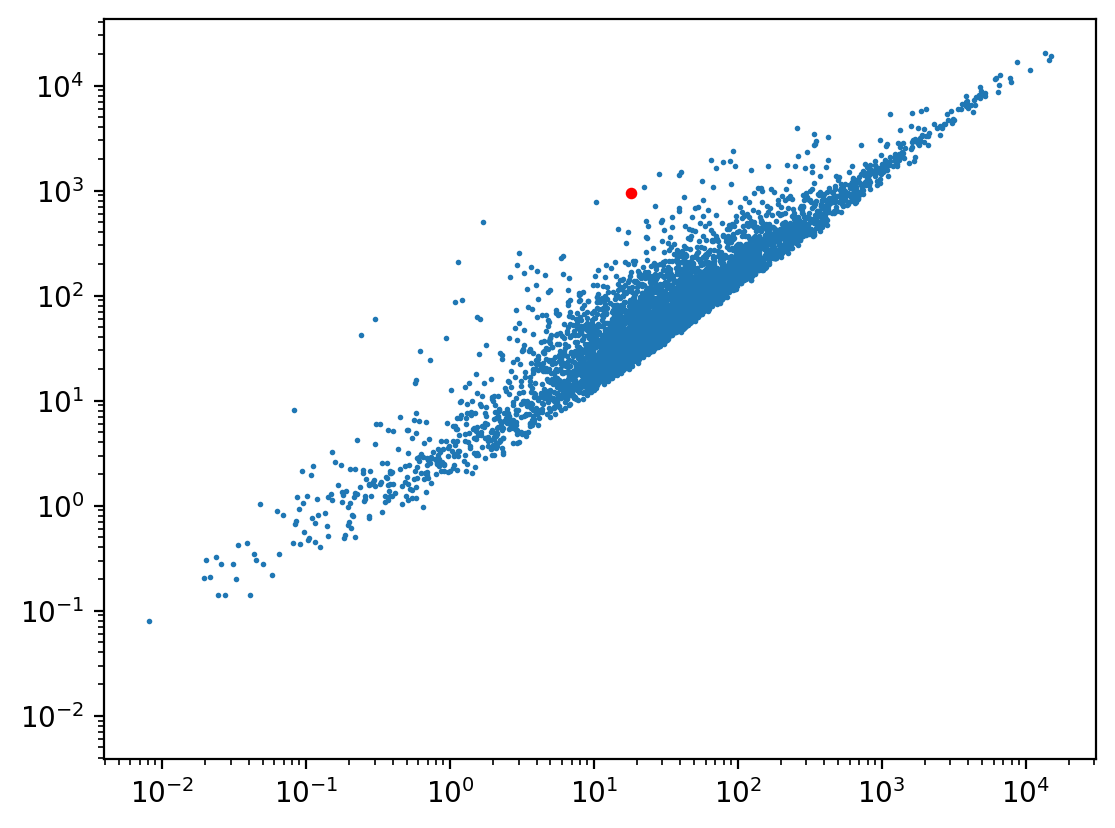

In [30]:
meta_vals = tpm_config.wt1_df[[]].copy()

min_vals = tpm_config.wt1_df.min(axis=1)
max_vals = tpm_config.wt1_df.max(axis=1)

meta_vals['mins'] = min_vals
meta_vals['maxs'] = max_vals

plt.scatter(meta_vals.mins, meta_vals.maxs, s=1)
plt.xscale('log')
plt.yscale('log')

sel = meta_vals.loc[tpm_model.orf_name]
plt.scatter(sel.mins, sel.maxs, s=10, c='red')

sel.mins, sel.maxs

In [41]:
np.max(tpm_model.g) / np.min(tpm_model.g)

51.68048149647253